In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataa.csv")

In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [4]:
X = df.iloc[: , 0:3].values
y= df.iloc[: , -1].values

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)
residual = y_test - y_pred

# Linear Relationship

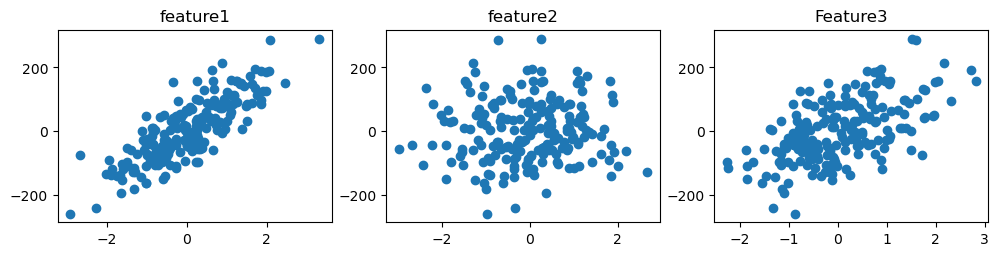

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("feature1")
ax2.scatter(df["feature2"], df["target"])
ax2.set_title("feature2")
ax3.scatter(df["feature3"], df["target"])
ax3.set_title("Feature3")
plt.show()

In [15]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.6 MB 22.2 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.6 MB 12.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 10.2 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 8.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 7.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.6 MB 6.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.0 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   ------------

# 2. Multicollinearity

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
vif = []
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [22]:
pd.DataFrame({'vif' : vif}, index = df.columns[:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: >

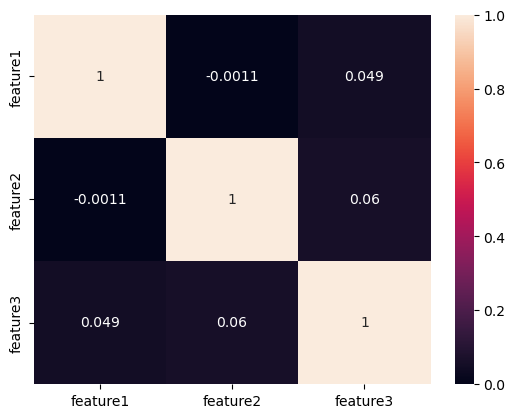

In [23]:
# Another technique
sns.heatmap(df.iloc[: , 0 : 3].corr(), annot = True)

# 3. Normality of Residual

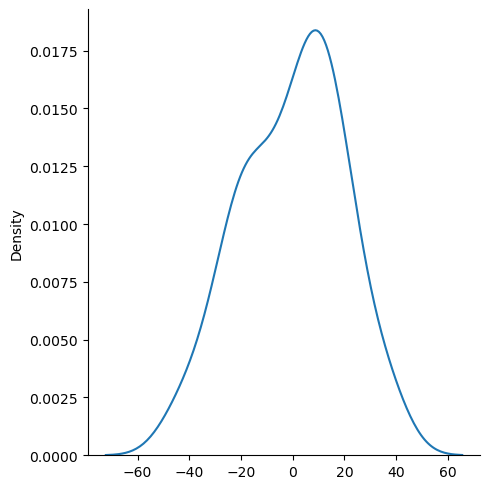

In [24]:
sns.displot(residual, kind = 'kde')

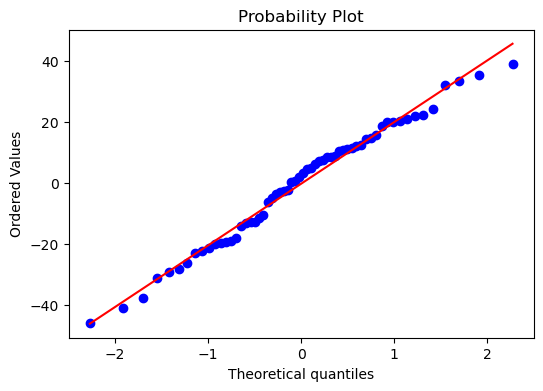

In [25]:
# QQ

import scipy as sp

fig, ax = plt.subplots(figsize=(6, 4))
sp.stats.probplot(residual, plot = ax, fit = True)
plt.show()

# 4. Homposcedasticity

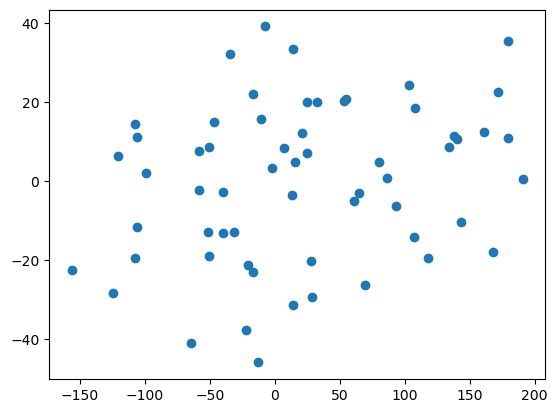

In [26]:
plt.scatter(y_pred, residual)

# 5. Autocorre;ation of Residuals

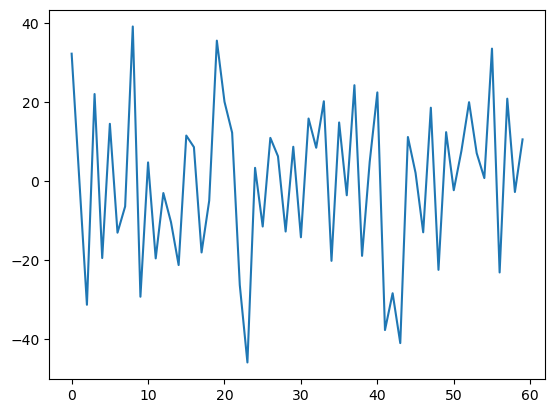

In [27]:
plt.plot(residual)